# Day 2 — Hands-On Lab: Activations & the Forward Pass

**Week 6 · Phase 3 Sprint 1 — Deep Learning Intro**

---

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain why non-linear activations are essential** — without them, stacking layers collapses into a single linear transformation.
2. **Visualize and compare** ReLU, Sigmoid, Tanh, and Softmax, including their derivatives (critical for backpropagation on Day 3).
3. **Choose the correct output activation and loss function** for your task and justify the choice mathematically.
4. **Implement a forward pass from scratch** in NumPy, tracking tensor shapes at every step.
5. **Compute the loss** (Binary Cross-Entropy) and verify the result analytically.

### Why Activations Matter

A neural network without activation functions is just a chain of linear operations:

$$W_2(W_1 x + b_1) + b_2 = W'x + b'$$

No matter how many layers you stack, the result is always a **single linear model**. Activation functions introduce **non-linearity**, which is the single ingredient that lets deep networks learn complex, curved decision boundaries.

### Prerequisites

- Weeks 1–5 completed (especially Week 2 dot product and Week 3–4 baseline models).
- Day 1 of this week: Sprint 1 baseline established.

---

## Step 1 — Plotting Activation Functions & Their Derivatives

We plot four common activation functions over the range $z \in [-6, 6]$ and their **derivatives**, because the derivative is what backpropagation (Day 3) uses to update weights.

| Function | Output Range | Typical Use |
|----------|-------------|-------------|
| **ReLU** | $[0, +\infty)$ | Hidden layers — the default, fast and effective |
| **Sigmoid** | $(0, 1)$ | Binary classification output — interpretable as probability |
| **Tanh** | $(-1, +1)$ | Hidden layers when zero-centered output helps |
| **Softmax** | $(0, 1)$, sums to 1 | Multi-class classification output — class probabilities |

Key observations to look for:
- **ReLU** is zero for all negative inputs -> sparse activations, fast computation, but "dying ReLU" problem.
- **Sigmoid** saturates at 0 and 1 -> gradients vanish for large $|z|$, slowing learning.
- **Tanh** is zero-centered -> often trains faster than sigmoid in hidden layers.
- **Softmax** normalizes a vector into a probability distribution -> only meaningful for the output layer.

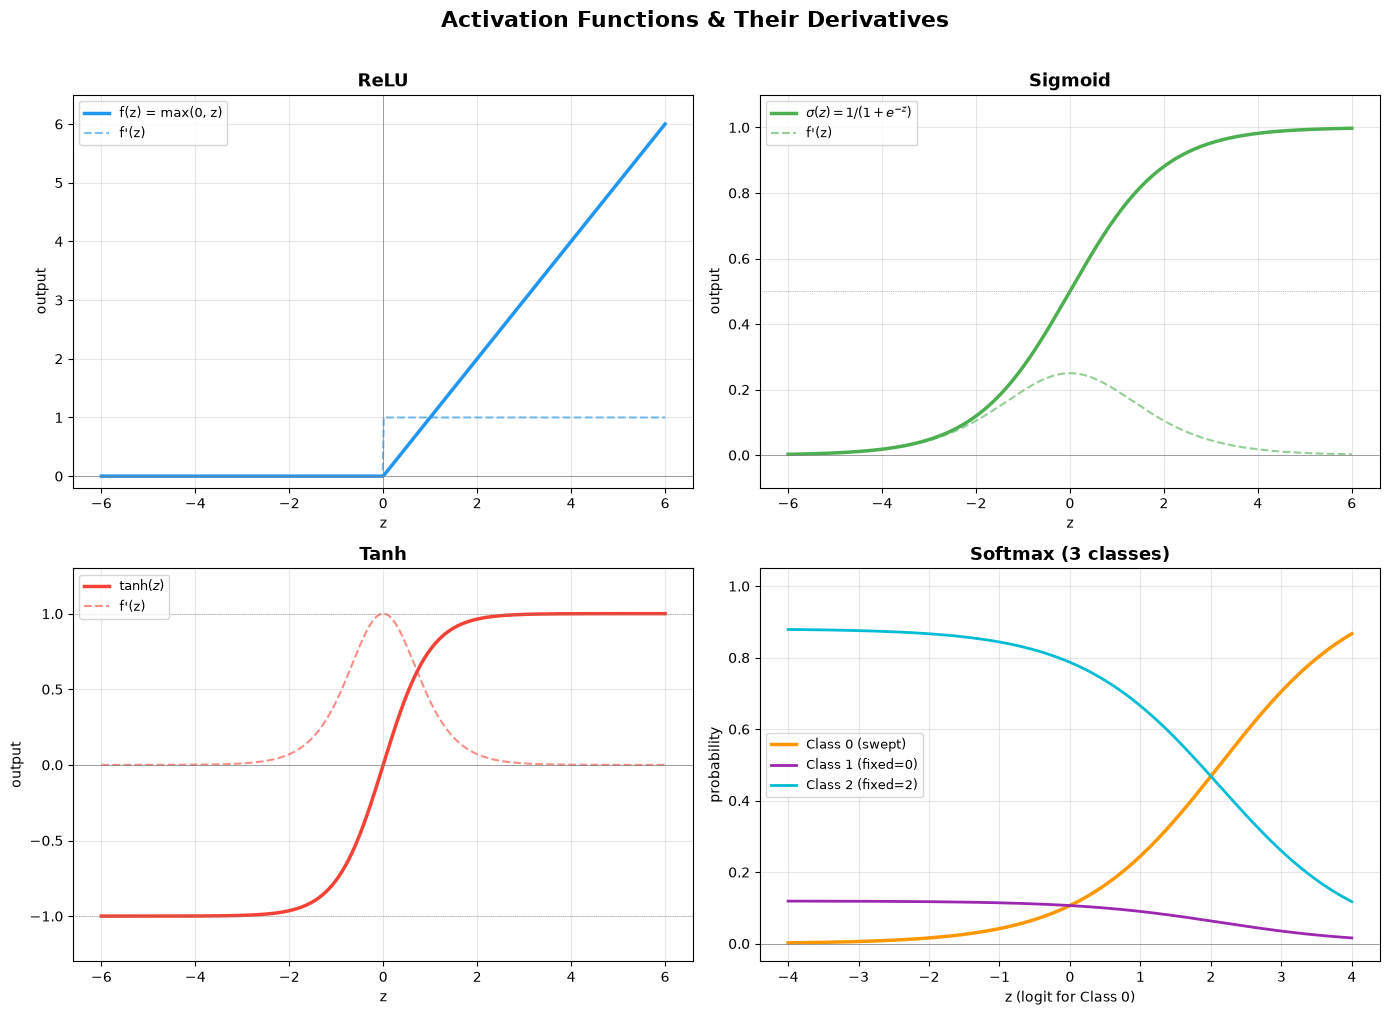

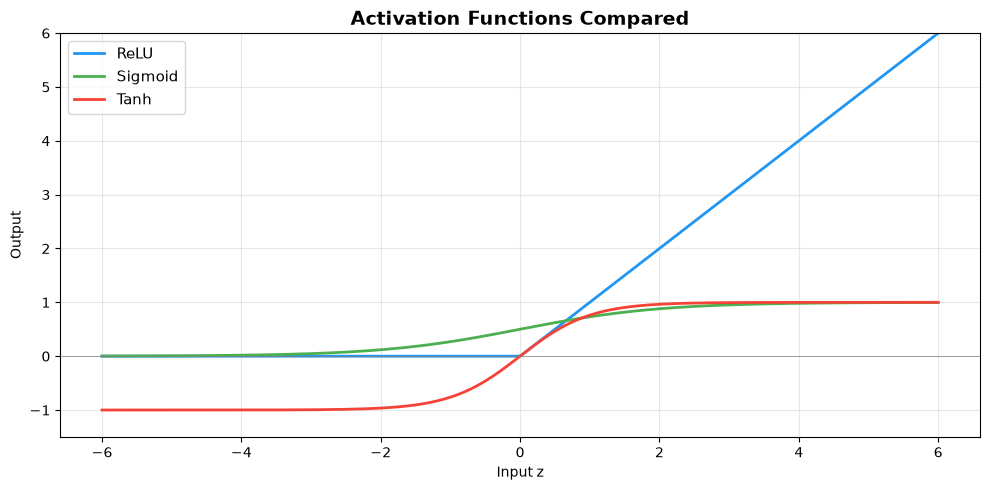

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Activation Functions & Derivatives
# ------------------------------------------------------------------
def relu(z):
    """ReLU: max(0, z). Derivative: 1 if z > 0, else 0."""
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    """Sigmoid: 1 / (1 + e^(-z)). Derivative: s * (1 - s)."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_act(z):
    """Tanh. Derivative: 1 - tanh(z)^2."""
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def softmax(z):
    """Softmax (numerically stable)."""
    e = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

# ------------------------------------------------------------------
# Input range
# ------------------------------------------------------------------
z = np.linspace(-6, 6, 500)

# ------------------------------------------------------------------
# Figure 1: Activation Functions (2x2 grid with derivatives)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Activation Functions & Their Derivatives', fontsize=16, fontweight='bold', y=1.01)

# --- ReLU ---
ax = axes[0, 0]
ax.plot(z, relu(z), color='#2196F3', linewidth=2.5, label='f(z) = max(0, z)')
ax.plot(z, relu_derivative(z), color='#2196F3', linewidth=1.5, linestyle='--', alpha=0.6, label="f'(z)")
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('ReLU', fontsize=13, fontweight='bold')
ax.set_xlabel('z')
ax.set_ylabel('output')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 6.5)

# --- Sigmoid ---
ax = axes[0, 1]
ax.plot(z, sigmoid(z), color='#4CAF50', linewidth=2.5, label=r'$\sigma(z) = 1/(1+e^{-z})$')
ax.plot(z, sigmoid_derivative(z), color='#4CAF50', linewidth=1.5, linestyle='--', alpha=0.6, label="f'(z)")
ax.axhline(y=0.5, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_title('Sigmoid', fontsize=13, fontweight='bold')
ax.set_xlabel('z')
ax.set_ylabel('output')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.1)

# --- Tanh ---
ax = axes[1, 0]
ax.plot(z, tanh_act(z), color='#F44336', linewidth=2.5, label=r'$\tanh(z)$')
ax.plot(z, tanh_derivative(z), color='#F44336', linewidth=1.5, linestyle='--', alpha=0.6, label="f'(z)")
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axhline(y=1, color='gray', linewidth=0.5, linestyle=':')
ax.axhline(y=-1, color='gray', linewidth=0.5, linestyle=':')
ax.set_title('Tanh', fontsize=13, fontweight='bold')
ax.set_xlabel('z')
ax.set_ylabel('output')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.3, 1.3)

# --- Softmax (3-class demo) ---
ax = axes[1, 1]
z_demo = np.linspace(-4, 4, 300)
logits = np.column_stack([z_demo, np.zeros(300), 2*np.ones(300)])
probs = softmax(logits)
ax.plot(z_demo, probs[:, 0], color='#FF9800', linewidth=2.5, label='Class 0 (swept)')
ax.plot(z_demo, probs[:, 1], color='#9C27B0', linewidth=2.0, label='Class 1 (fixed=0)')
ax.plot(z_demo, probs[:, 2], color='#00BCD4', linewidth=2.0, label='Class 2 (fixed=2)')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_title('Softmax (3 classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('z (logit for Class 0)')
ax.set_ylabel('probability')
ax.legend(loc='center left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Figure 2: Side-by-side comparison
# ------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(z, relu(z), color='#2196F3', linewidth=2, label='ReLU')
ax2.plot(z, sigmoid(z), color='#4CAF50', linewidth=2, label='Sigmoid')
ax2.plot(z, tanh_act(z), color='#F44336', linewidth=2, label='Tanh')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_title('Activation Functions Compared', fontsize=14, fontweight='bold')
ax2.set_xlabel('Input z')
ax2.set_ylabel('Output')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-1.5, 6)
plt.tight_layout()
plt.show()

---

## Step 2 — Choosing the Output Activation & Loss Function

### Our Task: Heart Disease Prediction (Binary Classification)

The Phase 3 project dataset (`heart_disease_processed.csv`) has a target variable **`target`**:
- `0` = no heart disease
- `1` = heart disease present

### Output Activation: **Sigmoid**

| Criterion | Reasoning |
|-----------|----------|
| **Output range** | Sigmoid maps any real number to $(0, 1)$, which is directly interpretable as $P(y=1 \mid X)$ |
| **Binary task** | For a single output neuron, sigmoid gives the probability of the positive class |
| **Gradient** | $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ -- smooth and differentiable everywhere |

> **When to use what:**
> - Binary classification -> **Sigmoid** (1 output neuron)
> - Multi-class classification -> **Softmax** ($K$ output neurons, one per class)
> - Regression -> **None / Linear** (output is unbounded)

### Loss Function: **Binary Cross-Entropy (BCE)**

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\Big[y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\Big]$$

| Criterion | Reasoning |
|-----------|----------|
| **Penalizes confident wrong predictions** | If $y=1$ and $\hat{y} \to 0$, the loss $\to +\infty$ -- strong gradient signal |
| **Convex** (with sigmoid) | Guarantees a single global minimum, making gradient descent effective |
| **Matches probability output** | BCE + sigmoid is the canonical pairing for binary classification |

> **When to use what:**
> - Binary classification -> **Binary Cross-Entropy**
> - Multi-class classification -> **Categorical Cross-Entropy**
> - Regression -> **Mean Squared Error (MSE)**

---

## Step 3 — Forward Pass: From Scratch in NumPy

We implement a **2-layer neural network** by hand, tracking tensor shapes at every step. This is exactly what Keras/PyTorch do under the hood.

### Network Architecture

```
Input (4 features)  ->  Hidden Layer (3 neurons, ReLU)  ->  Output (1 neuron, Sigmoid)
      X (1x4)              W1 (4x3), b1 (1x3)               W2 (3x1), b2 (1x1)
```

### Step-by-Step Formulas

1. **Hidden layer (linear):** $Z^{[1]} = X \cdot W^{[1]} + b^{[1]}$ -- shape: $(1, 4) \cdot (4, 3) + (1, 3) = (1, 3)$
2. **Hidden layer (activation):** $A^{[1]} = \text{ReLU}(Z^{[1]})$ -- shape: $(1, 3)$
3. **Output layer (linear):** $Z^{[2]} = A^{[1]} \cdot W^{[2]} + b^{[2]}$ -- shape: $(1, 3) \cdot (3, 1) + (1, 1) = (1, 1)$
4. **Output layer (activation):** $\hat{y} = \sigma(Z^{[2]})$ -- shape: $(1, 1)$
5. **Loss:** $\mathcal{L} = -[y \log(\hat{y}) + (1-y)\log(1-\hat{y})]$

In [2]:
import numpy as np

# ------------------------------------------------------------------
# Activation helpers (self-contained for this cell)
# ------------------------------------------------------------------
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ==================================================================
# FORWARD PASS -- 2-Layer Neural Network (from scratch)
# ==================================================================

# -- 0. Sample Patient Input -----------------------------------------
# Patient: age=54, trestbps=130, chol=236, thalach=174
# Values are on a normalized [0, 1] scale.
X_sample = np.array([[0.54, 0.65, 0.47, 0.79]])   # shape: (1, 4)
y_true   = np.array([[1]])                          # ground truth: heart disease present

print('Input X shape:', X_sample.shape)
print('Input X:')
print(X_sample)
print('True label y:', y_true[0][0])

# -- 1. Weight Initialization ----------------------------------------
np.random.seed(42)

# Hidden layer: 4 inputs -> 3 neurons
W1 = np.random.randn(4, 3) * 0.5  # scaled init for stable gradients
b1 = np.zeros((1, 3))

# Output layer: 3 inputs -> 1 neuron
W2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros((1, 1))

print()
print('W1 shape:', W1.shape, '  b1 shape:', b1.shape)
print('W2 shape:', W2.shape, '  b2 shape:', b2.shape)
print()
print('W1:')
print(np.array2string(W1, precision=4))
print()
print('W2:')
print(np.array2string(W2, precision=4))

# -- 2. Forward Pass -------------------------------------------------
# Layer 1: Linear
Z1 = np.dot(X_sample, W1) + b1          # (1,4).(4,3) + (1,3) = (1,3)
print()
print('-- Layer 1 --')
print('Z1 (linear) shape:', Z1.shape)
print('Z1:')
print(np.array2string(Z1, precision=4))

# Layer 1: ReLU activation
A1 = relu(Z1)                            # (1,3)
print()
print('A1 (ReLU) shape:', A1.shape)
print('A1:')
print(np.array2string(A1, precision=4))

# Layer 2: Linear
Z2 = np.dot(A1, W2) + b2                # (1,3).(3,1) + (1,1) = (1,1)
print()
print('-- Layer 2 --')
print('Z2 (linear) shape:', Z2.shape)
print('Z2:')
print(np.array2string(Z2, precision=4))

# Layer 2: Sigmoid activation
y_hat = sigmoid(Z2)                      # (1,1)
print()
print('y_hat (sigmoid) shape:', y_hat.shape)
print('y_hat =', round(float(y_hat[0][0]), 6))

# -- 3. Loss Computation (Binary Cross-Entropy) ----------------------
epsilon = 1e-15  # numerical stability: avoid log(0)
y_hat_clipped = np.clip(y_hat, epsilon, 1 - epsilon)

bce_loss = -(
    y_true * np.log(y_hat_clipped) +
    (1 - y_true) * np.log(1 - y_hat_clipped)
)

print()
print('-- Loss --')
print('Binary Cross-Entropy Loss:', round(float(bce_loss[0][0]), 6))

# -- 4. Verification -------------------------------------------------
manual_bce = -np.log(y_hat_clipped[0][0]) if y_true[0][0] == 1 else -np.log(1 - y_hat_clipped[0][0])
print()
print('-- Verification --')
print('Manual BCE (single-sample formula):', round(float(manual_bce), 6))
print('Match:', np.isclose(bce_loss[0][0], manual_bce))

Input X shape: (1, 4)
Input X:
[[0.54 0.65 0.47 0.79]]
True label y: 1

W1 shape: (4, 3)   b1 shape: (1, 3)
W2 shape: (3, 1)   b2 shape: (1, 1)

W1:
[[ 0.2484 -0.0691  0.3238]
 [ 0.7615 -0.1171 -0.1171]
 [ 0.7896  0.3837 -0.2347]
 [ 0.2713 -0.2317 -0.2329]]

W2:
[[ 0.121 ]
 [-0.9566]
 [-0.8625]]

-- Layer 1 --
Z1 (linear) shape: (1, 3)
Z1:
[[ 1.2145 -0.1161 -0.1955]]

A1 (ReLU) shape: (1, 3)
A1:
[[1.2145 0.     0.    ]]

-- Layer 2 --
Z2 (linear) shape: (1, 1)
Z2:
[[0.1469]]

y_hat (sigmoid) shape: (1, 1)
y_hat = 0.536668

-- Loss --
Binary Cross-Entropy Loss: 0.622376

-- Verification --
Manual BCE (single-sample formula): 0.622376
Match: True


---

## Step 4 — Summary & Key Takeaways

### What We Did

| Step | Outcome |
|------|---------|
| **Step 1** | Visualized ReLU, Sigmoid, Tanh, and Softmax with their derivatives -- the building blocks of every neural network |
| **Step 2** | Selected **Sigmoid** (output activation) + **Binary Cross-Entropy** (loss) for our binary classification task, with mathematical justification |
| **Step 3** | Implemented a full forward pass in NumPy: $X \to Z^{[1]} \to A^{[1]} \to Z^{[2]} \to \hat{y}$, tracked shapes, and computed the BCE loss |
| **Step 4** | Verified the loss computation analytically |

### Key Insights

1. **Activations are not optional** -- without them, depth is meaningless.
2. **ReLU is the default for hidden layers** -- simple, fast, effective. Watch for dying ReLU (neurons stuck at 0).
3. **Output activation must match the task** -- sigmoid for binary, softmax for multi-class, linear for regression.
4. **BCE + Sigmoid is a matched pair** -- the gradient simplifies nicely: $\frac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$.
5. **Shape tracking is essential** -- most forward-pass bugs are shape mismatches.

### Next: Day 3 -- Backpropagation & Gradient Descent

Now that we can compute a prediction (forward pass) and measure how wrong it is (loss), the next step is to **compute gradients** (backpropagation) and **update the weights** (gradient descent) to reduce the loss.